In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------
# 1. Load and process BC / chemistry data
# ------------------------------

# Load Zeppelin chemistry data
zeppelin = pd.read_csv("Zeppelin.csv")
zeppelin['datetime'] = pd.to_datetime(zeppelin['datetime'])
zeppelin.set_index('datetime', inplace=True)
zeppelin = zeppelin.apply(pd.to_numeric, errors='coerce')

# Rename columns to match the ATTO-style workflow
zeppelin = zeppelin.rename(columns={
    'BC': 'eBC'
})

# Keep only the needed chemistry columns
chem_hourly = zeppelin[['Org', 'Inorg', 'eBC']].copy()


# ------------------------------
# 2. Load SMPS data
# ------------------------------

zep_smps1 = pd.read_csv("Zeppelin mountain (Ny-Ålesund)_8BZJ-JARM.csv")

zep_smps1['time'] = pd.to_datetime(zep_smps1['time'])
zep_smps1.set_index('time', inplace=True)
zep_smps1 = zep_smps1.apply(pd.to_numeric, errors='coerce')

zep_smps2 = pd.read_csv("Zeppelin mountain (Ny-Ålesund)_DV3D-SEMG.csv")
zep_smps2['time'] = pd.to_datetime(zep_smps2['time'])
zep_smps2.set_index('time', inplace=True)
zep_smps2 = zep_smps2.apply(pd.to_numeric, errors='coerce')

# Combine PSD datasets
zep_smps = pd.concat([zep_smps1, zep_smps2])
zep_smps = zep_smps.sort_index()
zep_smps = zep_smps[~zep_smps.index.duplicated(keep='first')]

# SMPS diameters
diameters = np.array([
    10.0, 12.0, 14.0, 17.0, 21.0, 25.0, 30.0, 36.0, 43.0, 52.0,
    62.0, 74.0, 89.0, 107.0, 128.0, 154.0, 185.0, 222.0, 266.0,
    319.0, 383.0, 460.0, 552.0, 662.0, 800.0
])


# ------------------------------
# 3. Merge hourly datasets
# ------------------------------

combined_data = pd.merge_asof(
    chem_hourly.sort_index(),
    zep_smps.sort_index(),
    left_index=True,
    right_index=True,
    direction='nearest',
    tolerance=pd.Timedelta('30min')
)


# ------------------------------
# 4. Take absolute values for chemical concentrations
# ------------------------------

chem_cols = ["Org", "Inorg", "eBC"]
combined_data[chem_cols] = combined_data[chem_cols].abs()


# ------------------------------
# 5. Compute volume and mass fractions
# ------------------------------

# Define densities (g/cm³)
densities = {"BC": 1.8, "OM": 1.4, "IN": 1.67}

# Compute volume fractions
combined_data["V_OM"] = combined_data["Org"] / densities["OM"]
combined_data["V_IN"] = combined_data["Inorg"] / densities["IN"]
combined_data["V_BC"] = combined_data["eBC"] / densities["BC"]
combined_data["V_tot"] = combined_data["V_OM"] + combined_data["V_IN"] + combined_data["V_BC"]

combined_data["f_nonBC_vol"] = (combined_data["V_OM"] + combined_data["V_IN"]) * 100 / combined_data["V_tot"]

# Compute mass fractions
mass_total = combined_data["Org"] + combined_data["Inorg"] + combined_data["eBC"]
combined_data["f_nonBC_mass"] = (combined_data["Org"] + combined_data["Inorg"]) * 100 / mass_total

combined_clean = combined_data.dropna()


# ------------------------------
# 6. Save combined data
# ------------------------------

combined_clean.to_csv("Zeppelin_combined_clean.csv")


C:\Users\chinthaparthy\AppData\Local\Temp\ipykernel_18176\4182650793.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  zeppelin['datetime'] = pd.to_datetime(zeppelin['datetime'])


In [4]:
ds = pd.read_csv("Zeppelin_combined_clean.csv")

In [5]:
ds

,datetime,Org,Inorg,eBC,10.0,12.0,14.0,17.0,21.0,25.0,...,460.0,552.0,662.0,800.0,V_OM,V_IN,V_BC,V_tot,f_nonBC_vol,f_nonBC_mass
0,2016-05-06 05:30:00,0.3353,0.165971,0.165292,20.16,41.16,59.79,52.01,21.98,23.69,...,4.26,1.45,0.46,0.61,0.239500,0.099384,0.091829,0.430713,78.679783,75.202344
1,2016-05-06 06:30:00,0.3316,0.139582,0.158546,27.86,37.93,48.38,45.14,28.03,29.29,...,4.16,1.75,0.66,0.91,0.236857,0.083582,0.088081,0.408520,78.438987,74.823098
2,2016-05-06 07:30:00,0.2349,0.151994,0.126499,33.89,46.07,57.63,56.40,37.41,33.18,...,3.67,1.50,0.68,0.85,0.167786,0.091014,0.070277,0.329077,78.644160,75.360202
3,2016-05-06 08:30:00,0.1371,0.128957,0.116379,38.96,53.32,64.44,62.01,44.52,41.20,...,4.29,1.61,0.62,0.69,0.097929,0.077220,0.064655,0.239803,73.038323,69.569026
4,2016-05-06 09:30:00,0.1157,0.088902,0.124812,32.82,50.76,68.81,73.59,54.98,48.72,...,4.31,2.20,0.93,0.99,0.082643,0.053235,0.069340,0.205218,66.211473,62.110900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16660,2020-04-22 15:30:00,0.2283,0.071105,0.119967,8.51,8.55,9.97,13.88,18.26,20.44,...,21.72,6.06,1.08,0.46,0.163071,0.042578,0.066648,0.272298,75.523717,71.393655
16661,2020-04-22 16:30:00,0.1851,0.070743,0.120142,9.53,8.75,10.24,15.88,20.91,21.54,...,23.91,7.19,1.35,0.69,0.132214,0.042361,0.066746,0.241321,72.341579,68.046066
16662,2020-04-22 17:30:00,0.1819,0.070108,0.105436,7.67,11.34,14.43,15.40,15.49,18.62,...,21.93,6.62,1.34,0.76,0.129929,0.041981,0.058576,0.230485,74.585954,70.502792
16663,2020-04-22 18:30:00,0.2214,0.070115,0.156868,6.32,8.15,11.27,16.89,21.21,19.88,...,21.98,6.09,1.08,0.61,0.158143,0.041985,0.087149,0.287277,69.663789,65.014731


In [7]:
ds

,datetime,Org,Inorg,eBC,10.0,12.0,14.0,17.0,21.0,25.0,...,460.0,552.0,662.0,800.0,V_OM,V_IN,V_BC,V_tot,f_nonBC_vol,f_nonBC_mass
0,2016-05-06 05:30:00,0.3353,0.165971,0.165292,20.16,41.16,59.79,52.01,21.98,23.69,...,4.26,1.45,0.46,0.61,0.239500,0.099384,0.091829,0.430713,78.679783,75.202344
1,2016-05-06 06:30:00,0.3316,0.139582,0.158546,27.86,37.93,48.38,45.14,28.03,29.29,...,4.16,1.75,0.66,0.91,0.236857,0.083582,0.088081,0.408520,78.438987,74.823098
2,2016-05-06 07:30:00,0.2349,0.151994,0.126499,33.89,46.07,57.63,56.40,37.41,33.18,...,3.67,1.50,0.68,0.85,0.167786,0.091014,0.070277,0.329077,78.644160,75.360202
3,2016-05-06 08:30:00,0.1371,0.128957,0.116379,38.96,53.32,64.44,62.01,44.52,41.20,...,4.29,1.61,0.62,0.69,0.097929,0.077220,0.064655,0.239803,73.038323,69.569026
4,2016-05-06 09:30:00,0.1157,0.088902,0.124812,32.82,50.76,68.81,73.59,54.98,48.72,...,4.31,2.20,0.93,0.99,0.082643,0.053235,0.069340,0.205218,66.211473,62.110900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16660,2020-04-22 15:30:00,0.2283,0.071105,0.119967,8.51,8.55,9.97,13.88,18.26,20.44,...,21.72,6.06,1.08,0.46,0.163071,0.042578,0.066648,0.272298,75.523717,71.393655
16661,2020-04-22 16:30:00,0.1851,0.070743,0.120142,9.53,8.75,10.24,15.88,20.91,21.54,...,23.91,7.19,1.35,0.69,0.132214,0.042361,0.066746,0.241321,72.341579,68.046066
16662,2020-04-22 17:30:00,0.1819,0.070108,0.105436,7.67,11.34,14.43,15.40,15.49,18.62,...,21.93,6.62,1.34,0.76,0.129929,0.041981,0.058576,0.230485,74.585954,70.502792
16663,2020-04-22 18:30:00,0.2214,0.070115,0.156868,6.32,8.15,11.27,16.89,21.21,19.88,...,21.98,6.09,1.08,0.61,0.158143,0.041985,0.087149,0.287277,69.663789,65.014731


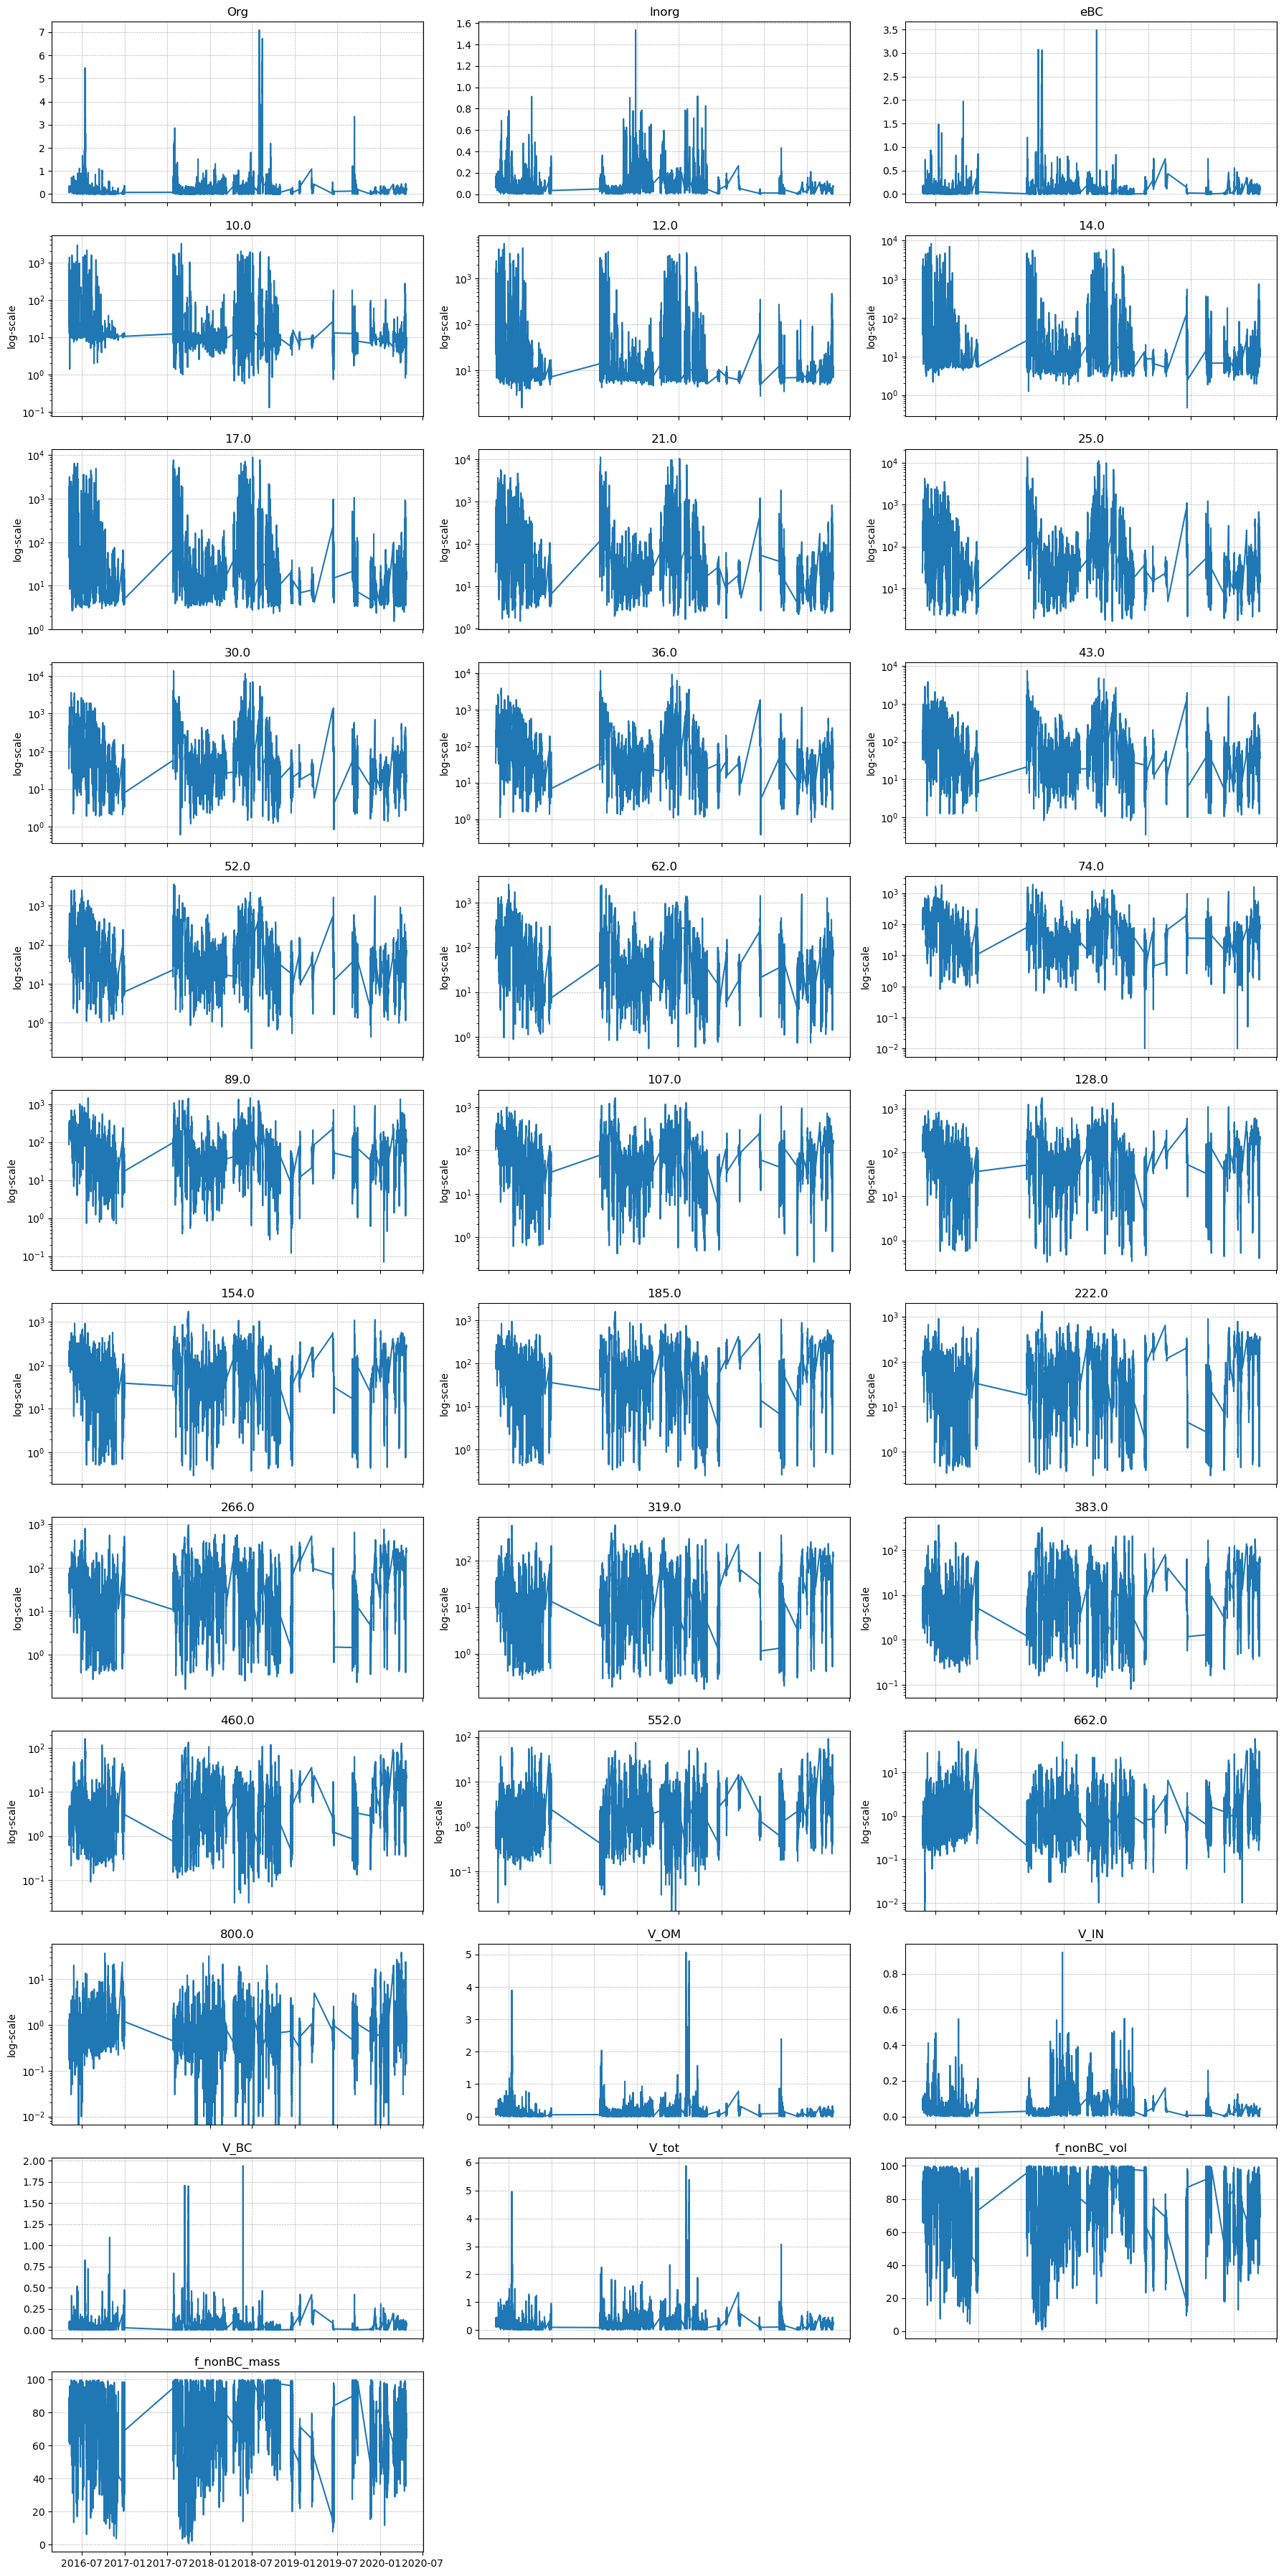

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


# --- Load combined dataset ---
combined = pd.read_csv("Zeppelin_combined_clean.csv")

# If saved with index=True (default), the datetime will usually be in 'datetime'
# or sometimes 'Unnamed: 0' depending on how it was written
if "datetime" in combined.columns:
    combined["Time"] = pd.to_datetime(combined["datetime"], errors="coerce")
elif "Unnamed: 0" in combined.columns:
    combined["Time"] = pd.to_datetime(combined["Unnamed: 0"], errors="coerce")
else:
    raise ValueError("No datetime column found in Zeppelin_combined_clean.csv")


# --- Identify SMPS bins ---
diameters = [
    10.0, 12.0, 14.0, 17.0, 21.0, 25.0, 30.0, 36.0, 43.0, 52.0,
    62.0, 74.0, 89.0, 107.0, 128.0, 154.0, 185.0, 222.0, 266.0,
    319.0, 383.0, 460.0, 552.0, 662.0, 800.0
]

smps_cols = [str(d) for d in diameters]


# --- Select numeric variables ---
numeric_cols = combined.select_dtypes(include=["float64", "int64"]).columns


# --- Plot ---
ncols = 3
nrows = (len(numeric_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3 * nrows), sharex=True)
axes = axes.flatten()


for i, col in enumerate(numeric_cols):
    axes[i].plot(combined["Time"], combined[col])
    axes[i].set_title(col)

    # Log scale for SMPS vars
    if col in smps_cols:
        axes[i].set_yscale("log")
        axes[i].set_ylabel("log-scale")

    axes[i].grid(True, ls="--", lw=0.5)


# remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()
